# Image Manipulation using NUmpy and PIL

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [13]:
# read an image file
pil_image = Image.open('cat_large.jpg')
# convert to numpy array
np_image = np.array(pil_image)

In [19]:
print(np_image.shape) # axis2=rgb channel. 1 pixel.
print(np_image.dtype) # 24bit rgb?
# print(np_image)

(1280, 1920, 3)
uint8


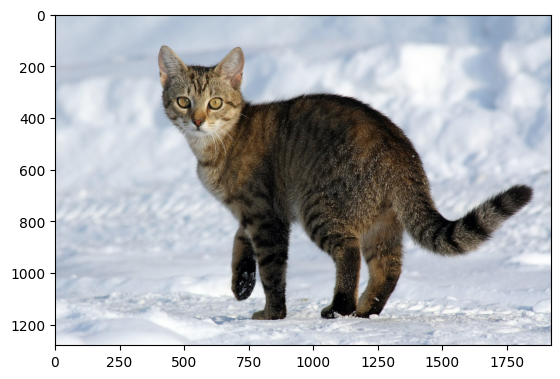

In [29]:
# display
plt.imshow(np_image[:,:,:])

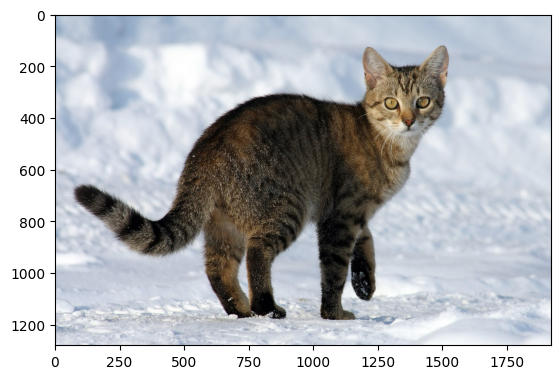

In [ ]:
plt.imshow(np_image[:,::-1,:])

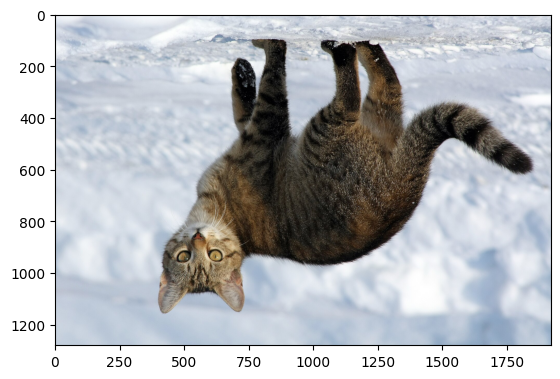

In [27]:
plt.imshow(np_image[::-1,:,:])

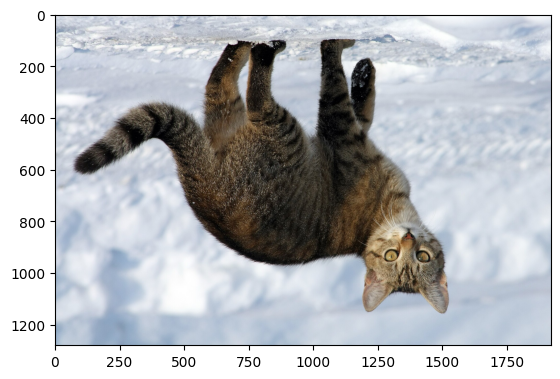

In [28]:
plt.imshow(np_image[::-1,::-1,:])

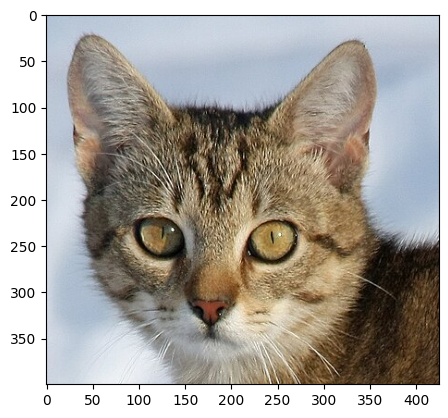

In [30]:
plt.imshow(np_image[100:500,375:800,:])

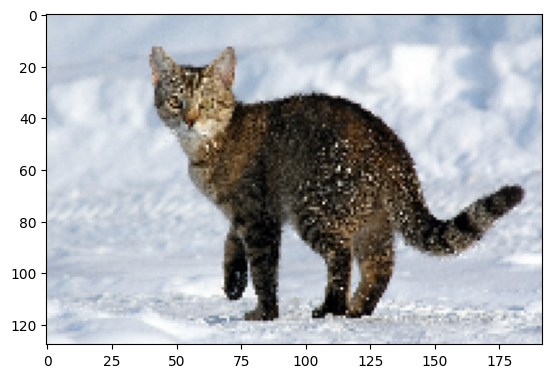

In [42]:
# downscaling
plt.imshow(np_image[::10,::10,:])

In [146]:
pil_image = Image.fromarray(np_image[::10,::10,:])
pil_image.save('cat_scaled.jpeg')

In [495]:
def better_downscale(np_image, scale_factor=1):
    ax0 = np_image.shape[0] // scale_factor
    ax1 = np_image.shape[1] // scale_factor
    split = np_image.reshape((ax0, scale_factor, ax1, scale_factor, -1))
    return split.sum(axis=(1, 3)) // (split.shape[1] * split.shape[3])

In [506]:
def better_downscale2(np_image, scale_factor=1):
    new_image = np.empty_like(np_image[::scale_factor,::scale_factor,:])
    for i in range(0, np_image.shape[0], scale_factor):
        for j in range(0, np_image.shape[1], scale_factor):
            new_image[i//scale_factor,j//scale_factor,:] = np_image[i:i+scale_factor,j:j+scale_factor,:].mean(axis=(0,1))
    return new_image

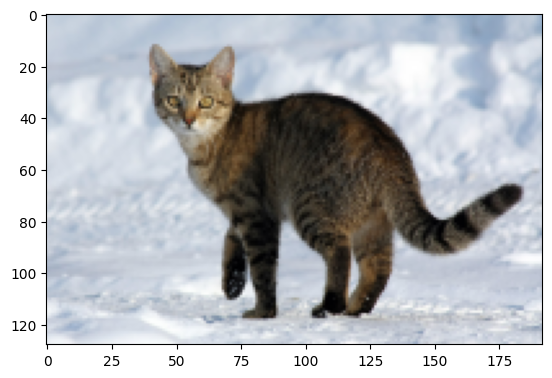

In [520]:
a = better_downscale2(np_image,10)
plt.imshow(a)

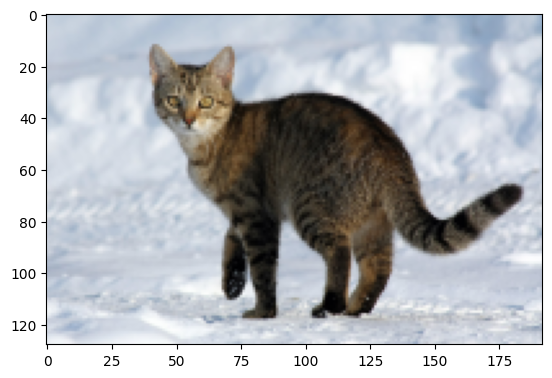

In [519]:
b = better_downscale(np_image,10)
plt.imshow(b)

In [204]:
np_image.shape

(1280, 1920, 3)

In [411]:
a = np.arange(1,101)
# print(a)
# print(a.shape) # 100
b = a.reshape((10,-1))
print(b)
print(b.shape)
# print(b.T)
# print(b.shape) # 10x10
c = b.reshape((2,5,2,5))
print(c[0,:,0,:])
print(c[0,:,0,:].mean())
print(c.mean(axis=(1,3)))


[[  1   2   3   4   5   6   7   8   9  10]
 [ 11  12  13  14  15  16  17  18  19  20]
 [ 21  22  23  24  25  26  27  28  29  30]
 [ 31  32  33  34  35  36  37  38  39  40]
 [ 41  42  43  44  45  46  47  48  49  50]
 [ 51  52  53  54  55  56  57  58  59  60]
 [ 61  62  63  64  65  66  67  68  69  70]
 [ 71  72  73  74  75  76  77  78  79  80]
 [ 81  82  83  84  85  86  87  88  89  90]
 [ 91  92  93  94  95  96  97  98  99 100]]
(10, 10)
[[ 1  2  3  4  5]
 [11 12 13 14 15]
 [21 22 23 24 25]
 [31 32 33 34 35]
 [41 42 43 44 45]]
23.0
[[23. 28.]
 [73. 78.]]


In [ ]:
np.count